/home/stk/projects/automatic-potato/out/solutions


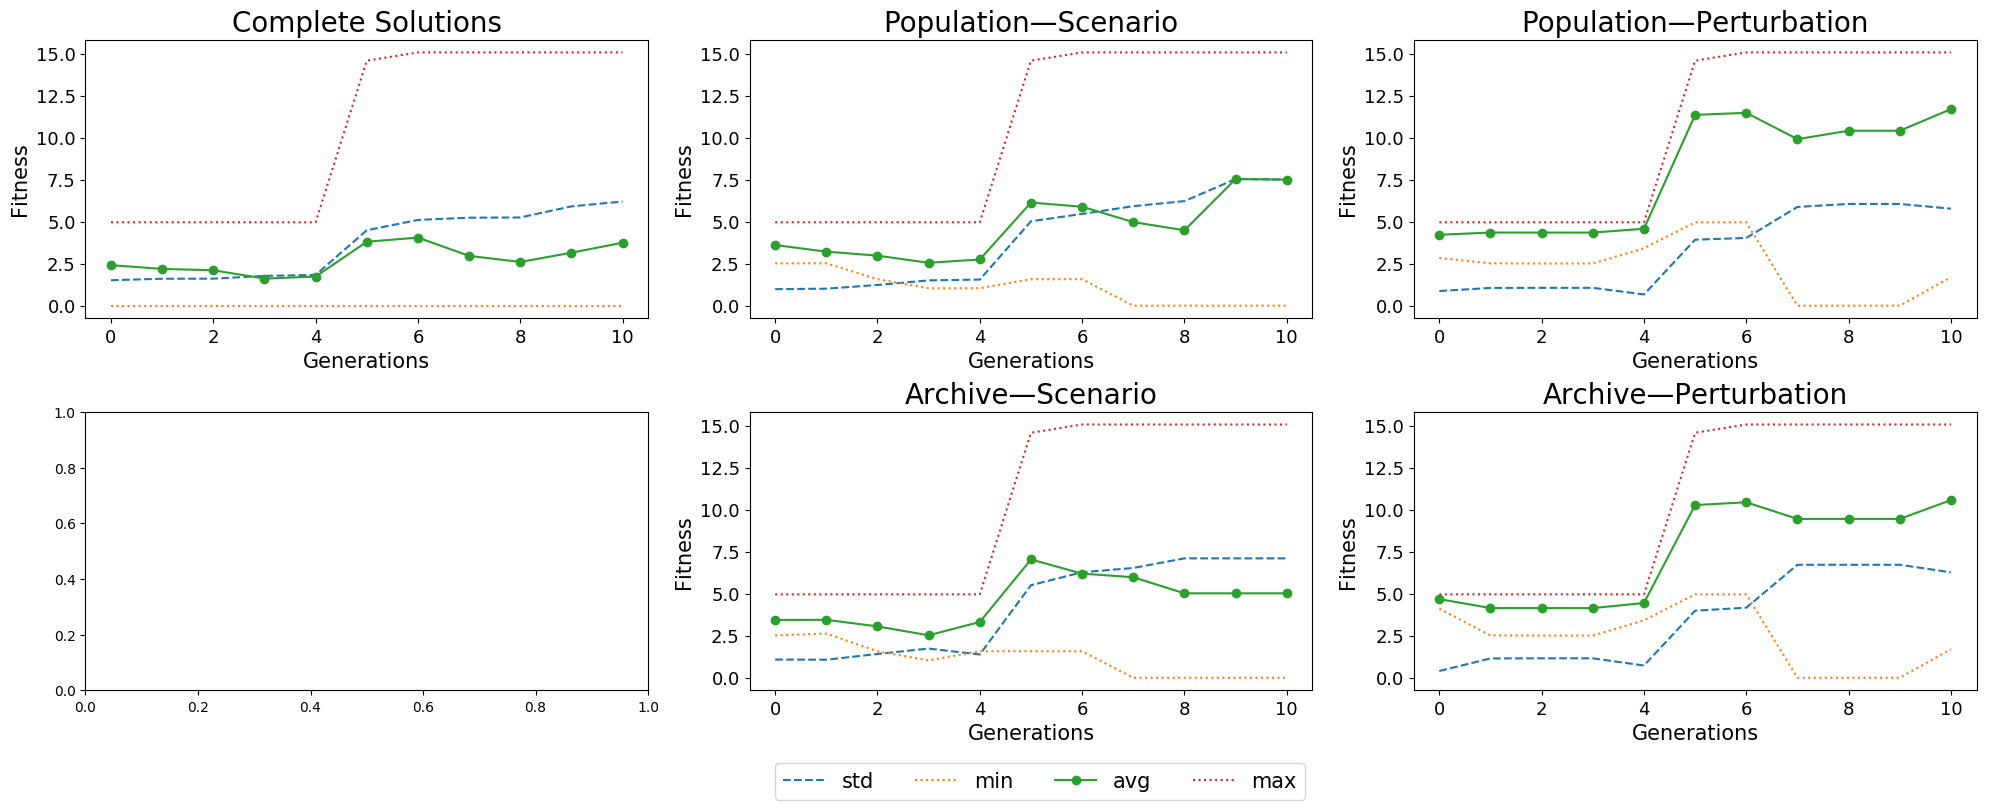

In [40]:
import pickle

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

%cd "/home/stk/projects/automatic-potato/out/solutions"
path = "statistics-1714746509540.pickle"
with open(path, "rb") as f:
    logbook = pickle.load(f)
stats = pd.DataFrame(logbook)
for metric in ["std", "min", "avg", "max"]:
    stats[metric] = stats[metric].apply(lambda x: x[0])
verbose = {"pop_scen": "Population—Scenario",
           "pop_pert": "Population—Perturbation",
           "arc_scen": "Archive—Scenario",
           "arc_pert": "Archive—Perturbation",
           "solution": "Complete Solutions"}

fig, axs = plt.subplots(2, 3, figsize=[20, 8])
pos = (1, 0)
# axs[pos].plot(pop["gen"], data[0]["num"], "o-C4", label="#simulations")
# axs[pos].plot(pop["gen"], data[0]["violated"], "o-C5", label="#violations")
# axs[pos].set_title("#Simulations & #Violations", fontsize=20)
# axs[pos].set_xlabel("Generations", fontsize=15)
# axs[pos].set_ylabel("Num", fontsize=15)
# axs[pos].tick_params(labelsize=13)
# axs[pos].xaxis.set_major_locator(MaxNLocator(integer=True))
# axs[pos].legend(fontsize=15)
for (pop_name, pop), pos in zip(stats.groupby("pop", sort=False), [(0, 1), (0, 2), (0, 0), (1, 1), (1, 2)]):
    pop = pop.sort_values("gen", ascending=True)
    axs[pos].plot(pop["gen"], pop["std"], "--C0", label="std")
    axs[pos].plot(pop["gen"], pop["min"], ":C1", label="min")
    axs[pos].plot(pop["gen"], pop["avg"], "o-C2", label="avg")
    axs[pos].plot(pop["gen"], pop["max"], ":C3", label="max")
    axs[pos].set_title(verbose[pop_name], fontsize=20)
    axs[pos].set_xlabel("Generations", fontsize=15)
    axs[pos].set_ylabel("Fitness", fontsize=15)
    axs[pos].tick_params(labelsize=13)
    axs[pos].xaxis.set_major_locator(MaxNLocator(integer=True))

handles, labels = axs[pos].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.52, -0.01), ncol=4, fontsize=15)
fig.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()

/home/stk/projects/automatic-potato
is_violated: True, extent: 13.682343690320277


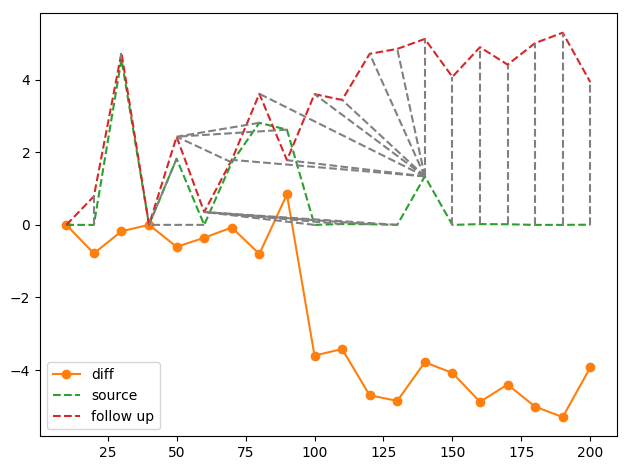

In [41]:
from impl import config
%cd "/home/stk/projects/automatic-potato/"
config.init_config()
from impl.problem import mr_set
import pandas as pd
import math
import matplotlib.pyplot as plt
from tslearn.metrics import dtw_path


def plot(_field, _source, _follow_up, _matches):
    _source["diff"] = _source[_field] - _follow_up[_field]
    fig, axs = plt.subplots()
    axs.plot(list(_source.index.values), list(_source["diff"]), "o-C1", label="diff")
    axs.plot(list(_source.index.values), list(_source[_field]), "--C2", label="source")
    axs.plot(list(_follow_up.index.values), list(_follow_up[_field]), "--C3", label="follow up")
    for i, j in _matches:
        axs.plot((_source.index.values[i], _follow_up.index.values[j]),
                 (_source.loc[_source.index.values[i], _field], _follow_up.loc[_follow_up.index.values[j], _field]),
                 "--", color="gray")
    axs.legend()
    fig.tight_layout()
    plt.show()


source = pd.read_csv("out/results/source.csv")
source.set_index(source.columns[0], inplace=True)
follow_up = pd.read_csv("out/results/follow-up.csv")
follow_up.set_index(follow_up.columns[0], inplace=True)

field = mr_set.field()
if field == "velocity":
    func = lambda row: math.sqrt(row.velocity_x ** 2 + row.velocity_y ** 2)
    source[field] = source.apply(func, axis=1, result_type="reduce")
    follow_up[field] = follow_up.apply(func, axis=1, result_type="reduce")
print("is_violated: {}, extent: {}".format(*mr_set.is_violated(source, follow_up)))

matches, _ = dtw_path(source[field], follow_up[field])
source[field] -= 0
plot(field, source, follow_up, matches)

In [ ]:
import carla

client = carla.Client("172.30.32.1", 2004)
world = client.load_world("Town05")
blueprint_library = world.get_blueprint_library()

In [2]:
ego = world.spawn_actor(blueprint_library.find("vehicle.lincoln.mkz2017"),
                        carla.Transform(carla.Location(x=-188.04, y=111.89, z=0.2),
                                        carla.Rotation(pitch=0.0, yaw=-90.0, roll=0.0)))

In [ ]:
import random

try:
    actor.destroy()
except Exception:
    pass
spawn_point = carla.Transform(carla.Location(x=random.uniform(-202.0, -178.0), y=random.uniform(77, 102), z=0),
                              carla.Rotation(yaw=random.uniform(-180.0, 180.0)))
print(spawn_point)
actor = world.spawn_actor(blueprint_library.find("static.prop.streetsign"), spawn_point)